# Daily Sports and Activities: Feature Level Fusion
Mejorando el HAR con fusión de features artesanales y automáticas

# 1. Base de datos

La base de datos se puede obtener en el siguiente enlace: 

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace: 

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 2. Método

## 2.1. Cargar los datos

In [8]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

In [9]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 2.2. Pre-proceso

Aplicamos filtro de mediana

In [12]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [13]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d

# First apply median filter
only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))


# Combine non-sensor and filtered sensor data
dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


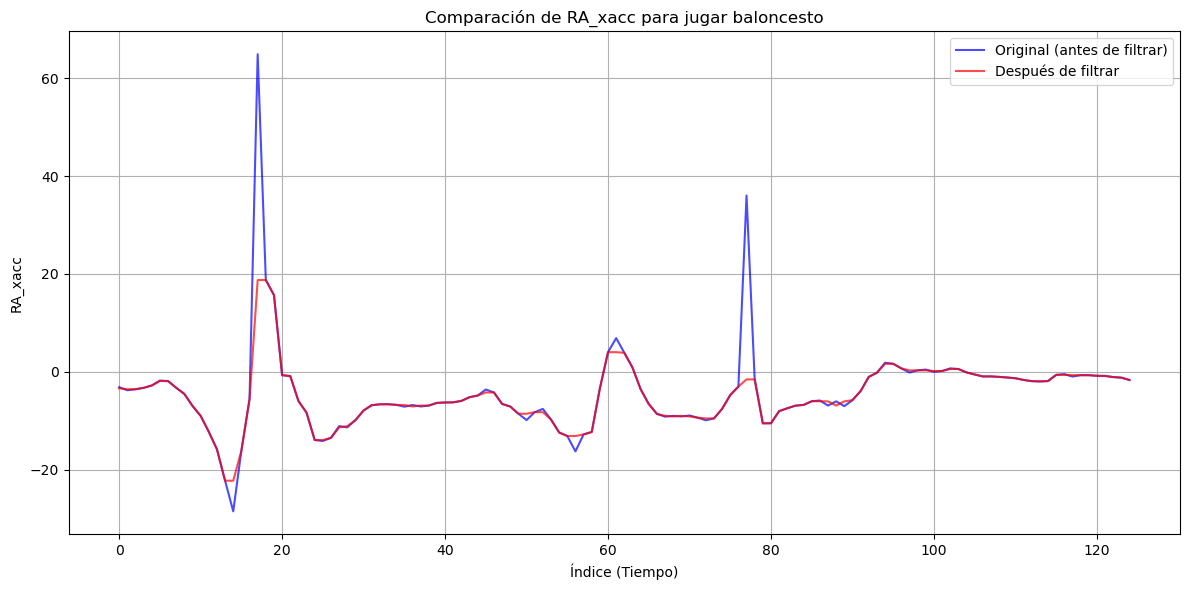

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2.3. Segmentación

In [16]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [17]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

In [18]:
dsaa_no_outlier3.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

In [19]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.4. Extracción de características

### 2.4.1. Características artesanales

In [22]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [23]:
import numpy as np
import pandas as pd

# Assume dsaa_no_outlier3 has a column 'person_id'
df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []
person_ids = []  # new list to collect person IDs

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Extract person ID (assuming column named 'person_id')
    pid = group["person_id"].iloc[0]

    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])
    person_ids.append(pid)  # add the person ID to the list

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Create DataFrame for person IDs
df_person_id = pd.DataFrame(person_ids, columns=["person_id"])

# Concatenate numeric features, labels, and person IDs
examples_fe_artesanal = pd.concat([df_numeric, df_labels, df_person_id], axis=1)

# Optionally, check the first few rows and data types
display(examples_fe_artesanal.head())
display(examples_fe_artesanal.dtypes)

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1


T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
person_id            object
Length: 242, dtype: object

In [24]:
examples_fe_artesanal

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


### 2.4.2. Características automáticas

In [26]:
meta_cols = ["activity_label","person_id","segment","segment_index","segment_3s"]
sensor_cols = [c for c in dsaa_no_outlier3.columns if c not in meta_cols]  

Tenemos:
- **1140000**: total de mediciones
- **45**: total de señales de sensores. 5 partes del cuerpo por 3 sensores con 3 ejes cada uno = 5x3x3 = 45

In [28]:
import numpy as np

data = dsaa_no_outlier3[sensor_cols].values  
data.shape

(1140000, 45)

In [29]:
groups = dsaa_no_outlier3.groupby("segment_3s")[sensor_cols]
segments = np.stack([grp.values for _, grp in groups], axis=0)

Tenemos:
- **15200**: Cantidad total de segmentos de 3s. 15200 porque 1140000 mediciones en todo el dataset los cuales segmentamos en 3s y como cada segundo es 25Hz terminamos con: total de mediciones / mediciones en un segmento = total de mediciones / (segundos * hz por segundo) = 1140000 / (3 * 25Hz) = 15200
- **75**: es el tamaño de 1 segmento. 75 porque 25Hz por 3s = 25*3 = 75 mediciones por segmento de 3s 
- **45**: La cantidad de sensores. 45 porque 5 partes del cuerpo x 3 sensores x 3 axis de cada sensor =  5*3*3 = 45

In [31]:
segments.shape

# segments.shape == (N, 75, C)
# N = nº de ventanas, 
# 75 = mediciones por ventana de 3s
# C = len(sensor_cols), cantidad de señales de sensores

(15200, 75, 45)

Model: "resnext_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 45)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 45)    │        180 │ input_layer[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 75, 64)    │     14,400 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 75, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 37, 64)    │          0 │ dropout[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 37, 64)    │      4,096 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 37, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 37, 64)    │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ concatenate[0][0

 Total params: 242,439 (947.03 KB)

 Trainable params: 238,381 (931.18 KB)

 Non-trainable params: 4,058 (15.85 KB)

None
Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.5446 - loss: 1.5951 - val_accuracy: 0.6658 - val_loss: 1.2234 - learning_rate: 5.0000e-04
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.9452 - loss: 0.1757 - val_accuracy: 0.7368 - val_loss: 1.2514 - learning_rate: 5.0000e-04
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9637 - loss: 0.1167 - val_accuracy: 0.7211 - val_loss: 1.3318 - learning_rate: 5.0000e-04
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9728 - loss: 0.0807 - val_accuracy: 0.7653 - val_loss: 1.7551 - learning_rate: 5.0000e-04
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9770 - loss: 0.0713 - val_accuracy: 0.7900 - val_loss: 0.7751 - learning_rate: 5.0000e-04
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.9808 - loss: 0.0611 - val_accuracy: 0.7805 - val_loss: 0.9235 - learning_rate: 5.0000e-04
Epoch 7/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 44m

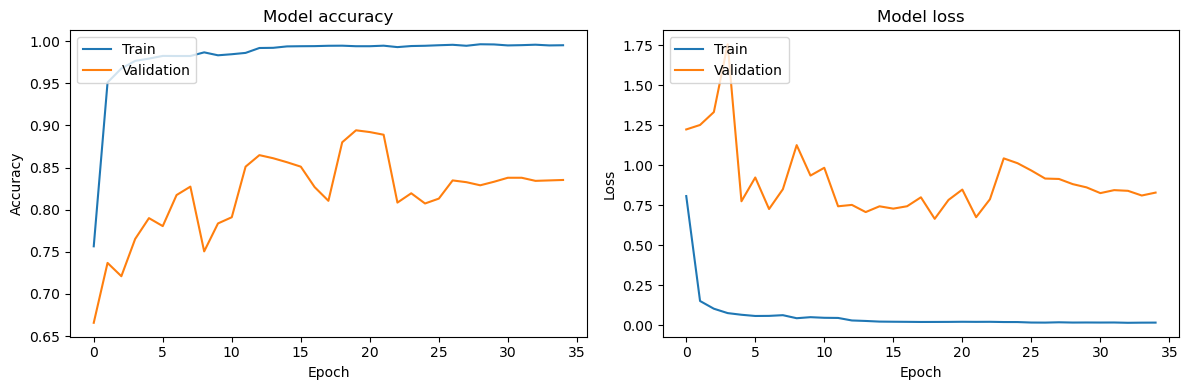

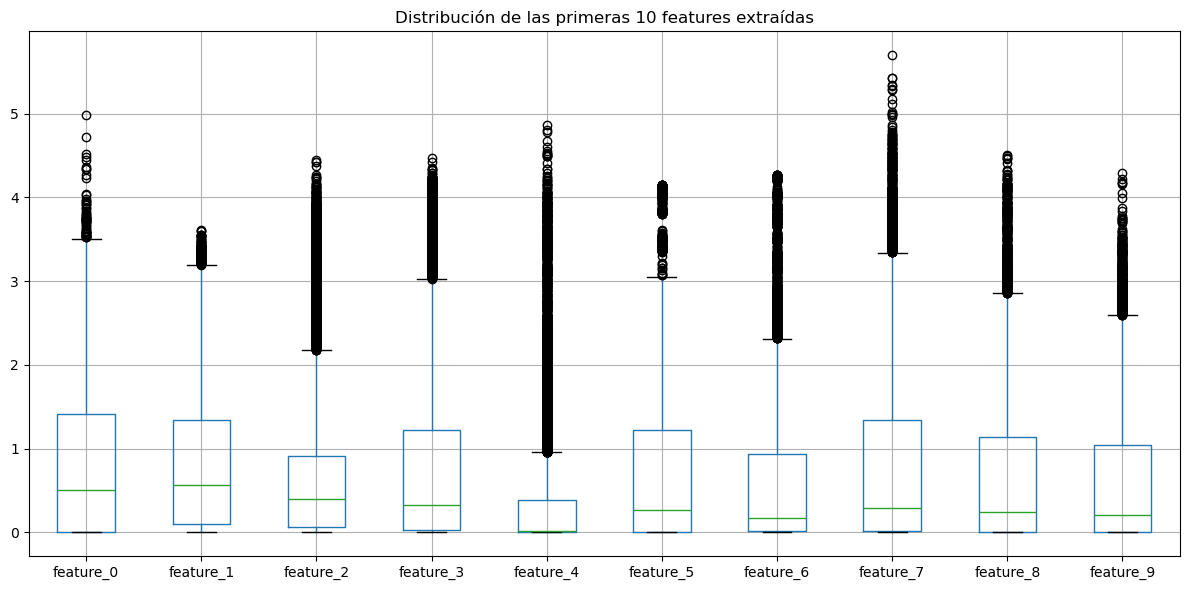

In [32]:
import numpy as np                                         # manejo de arrays
import pandas as pd                                        # DataFrame
from tensorflow.keras import layers, Model, Input          # Functional API
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# — 0) FUNCIONES PARA CREAR BLOQUES RESNEXT —
def resnext_block(x, filters, cardinality=8, strides=1, dropout_rate=0.2):
    """
    Implementa un bloque ResNeXt con cardinalidad y regularización
    Args:
        x: Input tensor
        filters: Número de filtros en la capa final del bloque
        cardinality: Número de grupos para la transformación (cardinalidad)
        strides: Stride para la primera capa de cada bloque
        dropout_rate: Tasa de dropout para regularización
    """
    # Guarda el input para la conexión residual
    shortcut = x
    
    # Split-Transform-Merge con cardinalidad
    # Primero reducimos la dimensionalidad
    reduced_filters = filters // 2
    
    x = layers.Conv1D(reduced_filters, kernel_size=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Transformación con cardinalidad
    # Usamos grupos de convolución para implementar cardinalidad
    groups = []
    group_width = max(1, reduced_filters // cardinality)  # Aseguramos al menos 1 filtro por grupo
    
    for i in range(cardinality):
        group = layers.Lambda(lambda z: z[:, :, i * group_width:(i + 1) * group_width 
                              if (i+1)*group_width <= reduced_filters else reduced_filters])(x)
        group = layers.Conv1D(group_width, kernel_size=3, strides=strides, 
                             padding='same', use_bias=False)(group)
        groups.append(group)
    
    # Concatenamos todos los grupos
    x = layers.Concatenate(axis=-1)(groups)
    
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Dropout para regularización
    x = layers.Dropout(dropout_rate)(x)
    
    # Expandimos de vuelta la dimensionalidad
    x = layers.Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Si cambiamos la dimensionalidad temporal o de canales, necesitamos
    # adaptar la conexión residual con una proyección 1x1
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, strides=strides, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Suma con la conexión residual
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    
    return x

# — 1) PREPARAR VENTANAS (N,75,C) Y ETIQUETAS —  
df = dsaa_no_outlier3                                     # tu DataFrame con segment_3s  
meta_cols = ["activity_label","person_id","segment","segment_index","segment_3s"]  
sensor_cols = [c for c in df.columns if c not in meta_cols]  # 45 columnas de sensor  
groups   = df.groupby("segment_3s")[sensor_cols]           # N grupos de 75 filas  
segments = np.stack([grp.values for _, grp in groups], axis=0)  # (N,75,45)  
labels     = df.groupby("segment_3s")["activity_label"].first().values  
person_ids = df.groupby("segment_3s")["person_id"].first().values  
N, T, C = segments.shape  # N ventanas, T=75, C=45  

# — 2) DEFINIR MODELO RESNEXT PARA EXTRACCIÓN DE FEATURES —  
inputs = Input(shape=(T, C))                    # capa Input (75, 45)

# Normalización de datos iniciales
x = layers.BatchNormalization()(inputs)

# Primera capa de convolución con regularización
x = layers.Conv1D(64, kernel_size=5, strides=1, padding='same', 
                 use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.MaxPooling1D(pool_size=2)(x)         # → (37, 64)

# Bloques ResNeXt con menor cardinalidad y regularización
# Reducimos la cardinalidad para evitar sobreajuste
# Primer grupo de bloques (64 filtros)
x = resnext_block(x, filters=128, cardinality=4, strides=1, dropout_rate=0.2)
x = resnext_block(x, filters=128, cardinality=4, strides=1, dropout_rate=0.2)
x = layers.MaxPooling1D(pool_size=2)(x)         # → (18, 128)

# Segundo grupo de bloques (128 filtros)
x = resnext_block(x, filters=256, cardinality=4, strides=1, dropout_rate=0.3)
x = resnext_block(x, filters=256, cardinality=4, strides=1, dropout_rate=0.3)

# Capa de pooling global para extracción de características
features = layers.GlobalAveragePooling1D()(x)    # → (256,)
features = layers.Dropout(0.5)(features)  # Fuerte regularización antes de la clasificación

# — 2.1) CREAR DOS MODELOS: UNO PARA ENTRENAR Y OTRO PARA EXTRAER CARACTERÍSTICAS —
# Modelo para entrenar (con capa de clasificación)
# Añadimos una capa de clasificación para entrenar el modelo
num_classes = len(np.unique(labels))
classification_output = layers.Dense(num_classes, activation='softmax', name='classification')(features)

# Modelo completo para entrenar
full_model = Model(inputs=inputs, outputs=classification_output, name='resnext_classifier')

# Modelo para extraer características (sin la capa de clasificación)
feature_extractor = Model(inputs=inputs, outputs=features, name='resnext_feature_extractor')

# Opcional: Mostrar resumen del modelo
print(full_model.summary())

# — 3) PREPARAR DATOS PARA ENTRENAMIENTO (TRAIN/VAL/TEST) —
# Convertir etiquetas a formato one-hot para entrenar
# Mapear las etiquetas a índices enteros
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
one_hot_labels = to_categorical(encoded_labels)

# Dividir datos para entrenamiento, validación y prueba
# Usamos person_id para asegurar que una persona no aparezca en diferentes conjuntos
unique_persons = np.unique(person_ids)
train_persons, temp_persons = train_test_split(unique_persons, test_size=0.3, random_state=42)
val_persons, test_persons = train_test_split(temp_persons, test_size=0.5, random_state=42)

# Crear máscaras para train, val y test
train_mask = np.isin(person_ids, train_persons)
val_mask = np.isin(person_ids, val_persons)
test_mask = np.isin(person_ids, test_persons)

X_train, y_train = segments[train_mask], one_hot_labels[train_mask]
X_val, y_val = segments[val_mask], one_hot_labels[val_mask]
X_test, y_test = segments[test_mask], one_hot_labels[test_mask]

# — 4) ENTRENAR EL MODELO —
# Compilar modelo con regularización en la pérdida
full_model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Menor tasa de aprendizaje
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks para mejorar el entrenamiento
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    # Opcional: Añadir TensorBoard para visualizar mejor el entrenamiento
    # tf.keras.callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)
]

# Data augmentation para reducir sobreajuste
def data_augmentation(x_batch, y_batch):
    # Añadir ruido aleatorio
    noise_factor = 0.05
    x_batch_noisy = x_batch + np.random.normal(0, noise_factor, x_batch.shape)
    # Time warping (estiramiento/compresión temporal simple)
    warped_batch = []
    for sample in x_batch_noisy:
        if np.random.random() > 0.5:
            # Simular time warping con interpolación
            indices = np.linspace(0, len(sample)-1, len(sample))
            warped_indices = indices + np.sin(np.linspace(0, np.pi, len(sample))) * 3
            warped_indices = np.clip(warped_indices, 0, len(sample)-1)
            warped_sample = np.array([np.interp(warped_indices, indices, sample[:,c]) for c in range(sample.shape[1])]).T
            warped_batch.append(warped_sample)
        else:
            warped_batch.append(sample)
    return np.array(warped_batch), y_batch

# Generador de datos con augmentation
def train_generator(x_data, y_data, batch_size=32):
    n_samples = len(x_data)
    while True:
        indices = np.random.permutation(n_samples)
        for i in range(0, n_samples, batch_size):
            batch_indices = indices[i:min(i+batch_size, n_samples)]
            x_batch, y_batch = x_data[batch_indices], y_data[batch_indices]
            # Aplicar data augmentation
            yield data_augmentation(x_batch, y_batch)

# Entrenar el modelo con data augmentation
epochs = 50
batch_size = 32  # Batch size más pequeño

history = full_model.fit(
    train_generator(X_train, y_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=(X_val, y_val),
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = full_model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# — 5) USAR EL MODELO ENTRENADO PARA EXTRAER CARACTERÍSTICAS —
# Ahora usamos el extractor de características entrenado
deep_features = feature_extractor.predict(segments, batch_size=64)  # (N, 256)

# — 6) MONTAR DataFrame FINAL —  
feat_cols = [f"feature_{i}" for i in range(deep_features.shape[1])]  # 256 nombres  
df_feats = pd.DataFrame(deep_features, columns=feat_cols)           # (N, 256)
df_feats["label"] = labels                                         # añade label
df_feats["person_id"] = person_ids                                 # añade person_id
examples_fe_resnext = df_feats

# Guardar el modelo entrenado
feature_extractor.save('resnext_feature_extractor.h5')

# Opcional: Visualizar la curva de aprendizaje
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

# Opcional: Visualizar distribución de features
plt.figure(figsize=(12, 6))
df_feats.iloc[:, :10].boxplot()
plt.title('Distribución de las primeras 10 features extraídas')
plt.tight_layout()
plt.show()

In [33]:
examples_fe_resnext

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_248,feature_249,feature_250,feature_251,feature_252,feature_253,feature_254,feature_255,label,person_id
0,1.630,1.547,0.575,0.541,0.000,0.624,2.730,0.561,0.318,0.000,...,0.532,0.000,0.004,0.005,0.455,0.323,0.570,2.107,a01,p1
1,1.621,1.578,0.629,0.430,0.000,0.695,2.793,0.519,0.403,0.000,...,0.485,0.000,0.005,0.006,0.563,0.274,0.441,2.166,a01,p1
2,1.619,1.612,0.642,0.369,0.000,0.757,2.855,0.454,0.467,0.000,...,0.460,0.000,0.005,0.004,0.620,0.265,0.418,2.184,a01,p1
3,1.622,1.600,0.634,0.383,0.000,0.736,2.843,0.468,0.460,0.000,...,0.471,0.000,0.005,0.005,0.598,0.268,0.441,2.177,a01,p1
4,1.619,1.605,0.633,0.384,0.000,0.738,2.848,0.461,0.466,0.000,...,0.468,0.000,0.005,0.004,0.596,0.268,0.442,2.177,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,1.489,0.126,0.094,0.000,0.880,1.730,1.278,0.511,0.369,0.119,...,1.759,1.165,0.251,0.000,0.463,0.768,0.064,0.296,a19,p8
15196,1.904,0.118,0.060,0.099,0.833,1.012,0.996,0.294,0.287,0.241,...,0.800,0.737,0.283,0.000,0.796,0.574,0.116,0.195,a19,p8
15197,2.309,0.049,0.000,0.000,0.935,0.971,1.102,1.985,0.212,0.393,...,1.993,1.801,0.000,0.015,0.857,1.310,0.074,0.026,a19,p8
15198,1.889,0.148,0.005,0.154,0.248,0.466,0.271,0.740,0.187,0.261,...,1.417,0.254,0.003,0.000,0.489,0.903,0.518,0.069,a19,p8


In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

def resnext_block(x, filters, cardinality=8, strides=1, dropout_rate=0.2):
    shortcut = x
    reduced_filters = filters // 2
    x = layers.Conv1D(reduced_filters, kernel_size=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    groups = []
    group_width = max(1, reduced_filters // cardinality)
    for i in range(cardinality):
        group = layers.Lambda(lambda z: z[:, :, i * group_width:(i + 1) * group_width
                              if (i+1)*group_width <= reduced_filters else reduced_filters])(x)
        group = layers.Conv1D(group_width, kernel_size=3, strides=strides,
                              padding='same', use_bias=False)(group)
        groups.append(group)

    x = layers.Concatenate(axis=-1)(groups)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, strides=strides,
                                 padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnext_feature_extractor(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = layers.BatchNormalization()(inputs)
    x = layers.Conv1D(64, kernel_size=5, strides=1, padding='same',
                      use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = resnext_block(x, filters=128, cardinality=4, strides=1, dropout_rate=0.2)
    x = resnext_block(x, filters=128, cardinality=4, strides=1, dropout_rate=0.2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = resnext_block(x, filters=256, cardinality=4, strides=1, dropout_rate=0.3)
    x = resnext_block(x, filters=256, cardinality=4, strides=1, dropout_rate=0.3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder

def cross_validate_resnext(X, y, num_classes, n_splits=5, epochs=50, batch_size=32):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded)):
        print(f"\nFold {fold + 1}/{n_splits}")
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
        y_train_cat = to_categorical(y_train, num_classes=num_classes)
        y_val_cat = to_categorical(y_val, num_classes=num_classes)

        model = build_resnext_feature_extractor(input_shape=X.shape[1:], num_classes=num_classes)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
        ]

        model.fit(X_train, y_train_cat,
                  validation_data=(X_val, y_val_cat),
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=callbacks,
                  verbose=1)

        y_val_pred_prob = model.predict(X_val)
        y_val_pred = y_val_pred_prob.argmax(axis=1)

        acc = accuracy_score(y_val, y_val_pred)
        prec = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")

        metrics['accuracy'].append(acc)
        metrics['precision'].append(prec)
        metrics['recall'].append(rec)
        metrics['f1'].append(f1)

    print("\nAverage Metrics:")
    for metric in metrics:
        avg = np.mean(metrics[metric])
        std = np.std(metrics[metric])
        print(f"{metric.capitalize()}: {avg:.4f} ± {std:.4f}")


In [36]:
# — 1) PREPARAR VENTANAS (N,75,C) Y ETIQUETAS —  
df = dsaa_no_outlier3                                     # tu DataFrame con segment_3s  
meta_cols = ["activity_label","person_id","segment","segment_index","segment_3s"]  
sensor_cols = [c for c in df.columns if c not in meta_cols]  # 45 columnas de sensor  
groups   = df.groupby("segment_3s")[sensor_cols]           # N grupos de 75 filas  
segments = np.stack([grp.values for _, grp in groups], axis=0)  # (N,75,45)  
labels     = df.groupby("segment_3s")["activity_label"].first().values  
person_ids = df.groupby("segment_3s")["person_id"].first().values  
N, T, C = segments.shape  # N ventanas, T=75, C=45  

num_classes = len(np.unique(labels))
cross_validate_resnext(segments, labels, num_classes=num_classes, n_splits=5, epochs=50, batch_size=32)



Fold 1/5
Epoch 1/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.6018 - loss: 1.3402 - val_accuracy: 0.9434 - val_loss: 0.1766 - learning_rate: 5.0000e-04
Epoch 2/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9492 - loss: 0.1626 - val_accuracy: 0.9694 - val_loss: 0.0974 - learning_rate: 5.0000e-04
Epoch 3/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9644 - loss: 0.1113 - val_accuracy: 0.9842 - val_loss: 0.0475 - learning_rate: 5.0000e-04
Epoch 4/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9738 - loss: 0.0897 - val_accuracy: 0.9806 - val_loss: 0.0531 - learning_rate: 5.0000e-04
Epoch 5/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9816 - loss: 0.0590 - val_accuracy: 0.9832 - val_loss: 0.0430 - learning_rate: 5.0000e-04
Epoch 6/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9850 - loss: 0.0543 - val_accuracy: 0.9849 - val_loss: 0.0468 - learning_rate: 5.0000e-04
Epoch 7/50
380/380 ━━━━━━━━━━━━━━━━━━━━ 14

KeyboardInterrupt: 

In [ ]:
segments.shape

### 2.4.3. Fusión de características

In [ ]:
examples_fe_artesanal

In [ ]:
examples_fe_resnext

In [ ]:
import pandas as pd

# Cargar los DataFrames
df_manuales = examples_fe_artesanal
df_resnext = examples_fe_resnext

# Eliminar columnas redundantes
df_manuales_clean = df_manuales.drop(columns=['activity', 'person_id'])
df_resnext_clean = df_resnext.drop(columns=['label', 'person_id'])

# Renombrar columnas de características para evitar conflictos
df_manuales_clean.columns = [f"artesanal_{col}" for col in df_manuales_clean.columns]
df_resnext_clean.columns = [f"resnext_{col}" for col in df_resnext_clean.columns]

# Concatenar los DataFrames
df_fusionado = pd.concat([df_manuales_clean, df_resnext_clean], axis=1)

# Añadir de nuevo las columnas de metadatos
df_fusionado['activity'] = df_manuales['activity']
df_fusionado['person_id'] = df_manuales['person_id']
df_fusionado

In [ ]:
df_fusionado.activity

In [ ]:
df_fusionado.person_id

## 2.5. Entrenamiento

### 2.5.1. Manuales

#### 2.5.1.1. Evaluación: Características manuales con Cross 10-K fold Cross-Validation

In [73]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro,
    controlando explicitamente zero_division=0.
    """
    # 1) Creamos los scorers con zero_division=0
    precision_macro_zd = make_scorer(
        precision_score,
        average='macro',
        zero_division=0
    )
    recall_macro_zd = make_scorer(
        recall_score,
        average='macro',
        zero_division=0
    )
    f1_macro_zd = make_scorer(
        f1_score,
        average='macro',
        zero_division=0
    )
    # accuracy no necesita zero_division
    accuracy_scorer = 'accuracy'

    # 2) Pipeline con escalado y modelo
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)

    # 3) Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False
    )

    # 4) Recolectar resultados por fold
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro":         cv_results["test_f1_macro"][i],
            "accuracy":         cv_results["test_accuracy"][i],
            "precision_macro":  cv_results["test_precision_macro"][i],
            "recall_macro":     cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    # 5) Función auxiliar para estadísticos
    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 6) Impresión de resultados
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))

    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))

    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")

    return scores, times, all_scores


Ejemplos:

In [75]:
X = examples_fe_artesanal.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_fe_artesanal.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Bayes Ingenuo:

In [77]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

Scores (F1-macro):
  0.9577  0.9680  0.9676  0.9585  0.9507
  0.9598  0.9641  0.9530  0.9593  0.9607

Media:              0.9599
Mediana:            0.9595
Std:                0.0053
Mínimo:             0.9507
Máximo:             0.9680

Tiempos de entrenamiento (s):
  0.2020  0.1420  0.1360  0.2050  0.1290
  0.1300  0.1390  0.1360  0.1350  0.1250

Media:              0.1479
Mediana:            0.1360
Std:                0.0282
Mínimo:             0.1250
Máximo:             0.2050


Regresión Logística:

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

Random Forest:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

Perceptron:

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

XGBoost:

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipelinear_crossvalidation(xgb, X, y_encoded)

AdaBoost:

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=3)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.2,
    algorithm="SAMME",
    random_state=42
)

ada_results = pipelinear_crossvalidation(ada, X, y_encoded)

In [ ]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metric     = compute_metrics(nb_results[idx])
lr_mean_metrics     = compute_metrics(lr_results[idx])
rf_mean_metrics     = compute_metrics(rf_results[idx])
percep_mean_metrics = compute_metrics(percep_results[idx])
xgb_mean_metrics    = compute_metrics(xgb_results[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metric,
    "Logistic Regression":  lr_mean_metrics,
    "Random Forest":        rf_mean_metrics,
    "Perceptron":           percep_mean_metrics,
    "XGBoost":              xgb_mean_metrics
}

df_metrics_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_cv.style.format(precision=5)

#### 2.5.1.2. Evaluación: Características manuales con Cross-Validation con Grupos usando 8 grupos. 

Para realizar la validación cruzada dejando fuera a 1 particiipante por ronda. Para esto se define una validación cruzada de 8 grupos, de modo que cada persona esté en el set de prueba en cada ronda siendo 8 rondas en total.

**Pipeline con Leave-one-out Cross Validation**: 

In [ ]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GroupKFold

def pipelinear_crossvalidation_groups(model, X, y, groups, n_splits=5):
    """
    Ajusta un pipeline (scaler + model) usando GroupKFold CV con 'n_splits' pliegues.
    Cada grupo indicado en 'groups' queda enteramente en train o en test.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento.
    
    Parámetros
    ----------
    model      : estimador de sklearn (clasificador)
    X          : array-like de características
    y          : array-like de etiquetas
    groups     : array-like de grupos (por ejemplo, person_id)
    n_splits   : número de pliegues para GroupKFold (por defecto 5)
    
    Devuelve
    --------
    scores     : array de f1_macro por pliegue
    times      : array de tiempos de fit por pliegue
    all_scores : lista de dicts con todas las métricas por pliegue
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # CV por grupos
    cv = GroupKFold(n_splits=n_splits)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # Compilar todas las métricas por pliegue
    all_scores = []
    n_splits_actual = cv.get_n_splits(X, y, groups)
    for i in range(n_splits_actual):
        all_scores.append({
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        })

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # Imprimir resultados
    print(f"GroupKFold con {n_splits_actual} pliegues — Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print("\nEstadísticas de F1-macro:")
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print("\nEstadísticas de tiempos de training:")
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

Dataset con labels e ids:

In [ ]:
# Preparamos X, y y groups
X = examples_fe_artesanal.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_fe_artesanal["activity"]
groups = examples_fe_artesanal["person_id"]

# Codificamos las etiquetas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
groups

**Bayes Ingenuo** con Cross-Validation en grupos agrupados por persona:

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=nb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

**Regresión Logística** con Cross-Validation en grupos agrupados por persona:

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=lr,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

**Bósque aleatorio** con Cross-Validation en grupos agrupados por persona:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=rf,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

**Perceptron** con Cross-Validation en grupos agrupados por persona:

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()

percep_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=perceptron,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

**XGBoost** con Cross-Validation en grupos agrupados por persona:

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=xgb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

AdaBoost:

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=3)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.2,
    algorithm="SAMME",
    random_state=42
)

ada_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=ada,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metrics_grouped     = compute_metrics(nb_results_grouped_by_person[idx])
lr_mean_metrics_grouped     = compute_metrics(lr_results_grouped_by_person[idx])
rf_mean_metrics_grouped     = compute_metrics(rf_results_grouped_by_person[idx])
percep_mean_metrics_grouped = compute_metrics(percep_results_grouped_by_person[idx])
xgb_mean_metrics_grouped    = compute_metrics(xgb_results_grouped_by_person[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metrics_grouped,
    "Logistic Regression":  lr_mean_metrics_grouped,
    "Random Forest":        rf_mean_metrics_grouped,
    "Perceptron":           percep_mean_metrics_grouped,
    "XGBoost":              xgb_mean_metrics_grouped
}

df_metrics_grouped_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_grouped_cv.style.format(precision=5)


### 2.5.2. Automáticas

#### 2.5.2.1. Evaluación: Características ResNeXt con Cross 10-K fold Cross-Validation

In [ ]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento, formateadas en columna.
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }
    
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [ ]:
X = examples_fe_resnext.drop(columns=["label", "person_id"], errors="ignore")
y = examples_fe_resnext.label

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipelinear_crossvalidation(xgb, X, y_encoded)

AdaBoost:

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=3)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.2,
    algorithm="SAMME",
    random_state=42
)

ada_results = pipelinear_crossvalidation(ada, X, y_encoded)

In [ ]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metric     = compute_metrics(nb_results[idx])
lr_mean_metrics     = compute_metrics(lr_results[idx])
rf_mean_metrics     = compute_metrics(rf_results[idx])
percep_mean_metrics = compute_metrics(percep_results[idx])
xgb_mean_metrics    = compute_metrics(xgb_results[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metric,
    "Logistic Regression":  lr_mean_metrics,
    "Random Forest":        rf_mean_metrics,
    "Perceptron":           percep_mean_metrics,
    "XGBoost":              xgb_mean_metrics
}

df_metrics_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_cv.style.format(precision=5)

#### 2.5.2.2. Evaluación: Características ResNeXt con Cross-Validation con Grupos usando 8 grupos. 

In [ ]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GroupKFold

def pipelinear_crossvalidation_groups(model, X, y, groups, n_splits=5):
    """
    Ajusta un pipeline (scaler + model) usando GroupKFold CV con 'n_splits' pliegues.
    Cada grupo indicado en 'groups' queda enteramente en train o en test.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento.
    
    Parámetros
    ----------
    model      : estimador de sklearn (clasificador)
    X          : array-like de características
    y          : array-like de etiquetas
    groups     : array-like de grupos (por ejemplo, person_id)
    n_splits   : número de pliegues para GroupKFold (por defecto 5)
    
    Devuelve
    --------
    scores     : array de f1_macro por pliegue
    times      : array de tiempos de fit por pliegue
    all_scores : lista de dicts con todas las métricas por pliegue
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # CV por grupos
    cv = GroupKFold(n_splits=n_splits)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # Compilar todas las métricas por pliegue
    all_scores = []
    n_splits_actual = cv.get_n_splits(X, y, groups)
    for i in range(n_splits_actual):
        all_scores.append({
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        })

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # Imprimir resultados
    print(f"GroupKFold con {n_splits_actual} pliegues — Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print("\nEstadísticas de F1-macro:")
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print("\nEstadísticas de tiempos de training:")
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [ ]:
X = examples_fe_resnext.drop(columns=["label", "person_id"], errors="ignore")
y = examples_fe_resnext.label

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Bayes Ingenuo:

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=nb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=lr,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=rf,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()

percep_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=perceptron,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=xgb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

AdaBoost:

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=3)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.2,
    algorithm="SAMME",
    random_state=42
)

ada_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=ada,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metrics_grouped     = compute_metrics(nb_results_grouped_by_person[idx])
lr_mean_metrics_grouped     = compute_metrics(lr_results_grouped_by_person[idx])
rf_mean_metrics_grouped     = compute_metrics(rf_results_grouped_by_person[idx])
percep_mean_metrics_grouped = compute_metrics(percep_results_grouped_by_person[idx])
xgb_mean_metrics_grouped    = compute_metrics(xgb_results_grouped_by_person[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metrics_grouped,
    "Logistic Regression":  lr_mean_metrics_grouped,
    "Random Forest":        rf_mean_metrics_grouped,
    "Perceptron":           percep_mean_metrics_grouped,
    "XGBoost":              xgb_mean_metrics_grouped
}

df_metrics_grouped_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_grouped_cv.style.format(precision=5)

### 2.5.3. Fusión a nivel de característica

#### 2.5.3.1. Evaluación: Características con Fusión a nivel de características con Cross 10-K fold Cross-Validation

Entrenamos los modelos:

In [ ]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento, formateadas en columna.
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }
    
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [ ]:
df_fusionado

In [ ]:
X = df_fusionado.drop(columns=["activity", "person_id"], errors="ignore")
y = df_fusionado["activity"]
groups = df_fusionado["person_id"]

# Codificamos las etiquetas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipelinear_crossvalidation(xgb, X, y_encoded)

AdaBoost:

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=3)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.2,
    algorithm="SAMME",
    random_state=42
)

ada_results = pipelinear_crossvalidation(ada, X, y_encoded)

In [ ]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metric     = compute_metrics(nb_results[idx])
lr_mean_metrics     = compute_metrics(lr_results[idx])
rf_mean_metrics     = compute_metrics(rf_results[idx])
percep_mean_metrics = compute_metrics(percep_results[idx])
xgb_mean_metrics    = compute_metrics(xgb_results[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metric,
    "Logistic Regression":  lr_mean_metrics,
    "Random Forest":        rf_mean_metrics,
    "Perceptron":           percep_mean_metrics,
    "XGBoost":              xgb_mean_metrics
}

df_metrics_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_cv.style.format(precision=5)

#### 2.5.3.2. Evaluación: Características con Fusión a nivel de características con Cross-Validation con Grupos usando 8 grupos. 

In [ ]:
df_fusionado

In [ ]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GroupKFold

def pipelinear_crossvalidation_groups(model, X, y, groups, n_splits=5):
    """
    Ajusta un pipeline (scaler + model) usando GroupKFold CV con 'n_splits' pliegues.
    Cada grupo indicado en 'groups' queda enteramente en train o en test.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento.
    
    Parámetros
    ----------
    model      : estimador de sklearn (clasificador)
    X          : array-like de características
    y          : array-like de etiquetas
    groups     : array-like de grupos (por ejemplo, person_id)
    n_splits   : número de pliegues para GroupKFold (por defecto 5)
    
    Devuelve
    --------
    scores     : array de f1_macro por pliegue
    times      : array de tiempos de fit por pliegue
    all_scores : lista de dicts con todas las métricas por pliegue
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # CV por grupos
    cv = GroupKFold(n_splits=n_splits)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # Compilar todas las métricas por pliegue
    all_scores = []
    n_splits_actual = cv.get_n_splits(X, y, groups)
    for i in range(n_splits_actual):
        all_scores.append({
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        })

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # Imprimir resultados
    print(f"GroupKFold con {n_splits_actual} pliegues — Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print("\nEstadísticas de F1-macro:")
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print("\nEstadísticas de tiempos de training:")
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [ ]:
X = df_fusionado.drop(columns=["activity", "person_id"], errors="ignore")
y = df_fusionado["activity"]
groups = df_fusionado["person_id"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=nb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=lr,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=rf,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()

percep_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=perceptron,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=xgb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

AdaBoost:

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=3)

ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=0.2,
    algorithm="SAMME",
    random_state=42
)

ada_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=ada,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

In [ ]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metrics_grouped     = compute_metrics(nb_results_grouped_by_person[idx])
lr_mean_metrics_grouped     = compute_metrics(lr_results_grouped_by_person[idx])
rf_mean_metrics_grouped     = compute_metrics(rf_results_grouped_by_person[idx])
percep_mean_metrics_grouped = compute_metrics(percep_results_grouped_by_person[idx])
xgb_mean_metrics_grouped    = compute_metrics(xgb_results_grouped_by_person[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metrics_grouped,
    "Logistic Regression":  lr_mean_metrics_grouped,
    "Random Forest":        rf_mean_metrics_grouped,
    "Perceptron":           percep_mean_metrics_grouped,
    "XGBoost":              xgb_mean_metrics_grouped
}

df_metrics_grouped_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_grouped_cv.style.format(precision=5) 

# A. Prueba: CNN con FE con CV

# NUEVO INTENTO

## 1. Manual

### 1.1 Feature Extractor por segmento

In [240]:
def artisanal_FE(time_segment):
    # Torso
    T_features = InertialSensor(time_segment.T_xacc, time_segment.T_yacc, time_segment.T_zacc).extract_features()
    T_gyro_features = InertialSensor(time_segment.T_xgyro, time_segment.T_ygyro, time_segment.T_zgyro).extract_features()
    T_mag_features = InertialSensor(time_segment.T_xmag, time_segment.T_ymag, time_segment.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(time_segment.RA_xacc, time_segment.RA_yacc, time_segment.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(time_segment.RA_xgyro, time_segment.RA_ygyro, time_segment.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(time_segment.RA_xmag, time_segment.RA_ymag, time_segment.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(time_segment.LA_xacc, time_segment.LA_yacc, time_segment.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(time_segment.LA_xgyro, time_segment.LA_ygyro, time_segment.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(time_segment.LA_xmag, time_segment.LA_ymag, time_segment.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(time_segment.RL_xacc, time_segment.RL_yacc, time_segment.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(time_segment.RL_xgyro, time_segment.RL_ygyro, time_segment.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(time_segment.RL_xmag, time_segment.RL_ymag, time_segment.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(time_segment.LL_xacc, time_segment.LL_yacc, time_segment.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(time_segment.LL_xgyro, time_segment.LL_ygyro, time_segment.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(time_segment.LL_xmag, time_segment.LL_ymag, time_segment.LL_zmag).extract_features()

    return np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)


### 1.2. Build DF for Feature Vectors from Segments

In [244]:
def build_feature_df_from_raw(raw_df):
    feature_vectors = []
    labels = []
    person_ids = []

    for segment_id, segment_df in raw_df.groupby("segment_3s"):
        feature_vector = artisanal_FE(segment_df)
        activity = segment_df["activity_label"].iloc[0]
        pid = segment_df["person_id"].iloc[0]

        feature_vectors.append(feature_vector)
        labels.append(activity)
        person_ids.append(pid)

    feature_columns = [
        f"{loc}_{typ}_{feat}"
        for loc in ["T", "RA", "LA", "RL", "LL"]
        for typ in ["acc", "gyro", "mag"]
        for feat in [
            "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
            "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
            "mean_mag", "std_mag", "auc", "mean_diff"
        ]
    ]

    df_features = pd.DataFrame(feature_vectors, columns=feature_columns)
    df_labels = pd.Series(labels, name="activity")
    df_persons = pd.Series(person_ids, name="person_id")

    return df_features, df_labels, df_persons


### 1.3. Pipelinear nuevo que usa el Modelo y el DF original

In [320]:
import time
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import cross_validate

def pipelinear_features_artesanales(modelo, full_raw_df):
    """
    CV 10 folds estratificada, dentro del loop extrae features artesanales,
    entrena scaler+modelo, mide f1/accuracy/precision/recall y fit_time.
    Imprime un reporte idéntico a `pipeleanear` y devuelve:
        scores (test_f1_macro array), times (fit_time array), all_scores (lista de dicts).
    """

    # 1) Preparamos la lista de segmentos y sus etiquetas originales
    all_segments = list(full_raw_df["segment_3s"].unique())
    all_labels   = full_raw_df.groupby("segment_3s")["activity_label"].first().values

    # 2) Creamos y entrenamos el LabelEncoder sobre todas las etiquetas
    encoder = LabelEncoder()
    encoder.fit(all_labels)

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    f1_scores = []
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    fit_times = []
    all_scores = []

    for train_idx, val_idx in skf.split(all_segments, all_labels):
        # Selección de raw_df por segmentos
        train_segs = [all_segments[i] for i in train_idx]
        val_segs   = [all_segments[i] for i in val_idx]

        train_df = full_raw_df[full_raw_df["segment_3s"].isin(train_segs)]
        val_df   = full_raw_df[full_raw_df["segment_3s"].isin(val_segs)]

        # EXTRAER FEATURES
        X_train, y_train_str, _ = build_feature_df_from_raw(train_df)
        X_val,   y_val_str,   _ = build_feature_df_from_raw(val_df)

        # ENCODIFICIÓN a enteros
        y_train = encoder.transform(y_train_str)
        y_val   = encoder.transform(y_val_str)

        # PIPELINE
        pipe = make_pipeline(StandardScaler(), modelo)

        # FIT + TIMING
        import time; start = time.time()
        pipe.fit(X_train, y_train)
        fit_times.append(time.time() - start)

        # PREDICT
        y_pred = pipe.predict(X_val)

        # MÉTRICAS
        f1   = f1_score(y_val, y_pred, average="macro", zero_division=0)
        acc  = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_val, y_pred, average="macro", zero_division=0)

        f1_scores.append(f1)
        accuracy_scores.append(acc)
        precision_scores.append(prec)
        recall_scores.append(rec)

        all_scores.append({
            "f1_macro":       f1,
            "accuracy":       acc,
            "precision_macro": prec,
            "recall_macro":    rec
        })

    # Convertir a numpy arrays
    scores = np.array(f1_scores)
    times  = np.array(fit_times)

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr)
        }

    # Impresión estilo pipeleanear
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    print()
    for label, val in stats_arr(scores).items():
        print(f"{label:<20}{val:.4f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    print()
    for label, val in stats_arr(times).items():
        print(f"{label:<20}{val:.4f}")

    return scores, times, all_scores


## 1.4. Entrenamiento

### 1.4.1. Bayes Ingenuo

In [304]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.naive_bayes import GaussianNB

modelo = GaussianNB()
nb_art_results = pipelinear_features_artesanales(modelo, df_to_extract_features2)
nb_art_results

Scores (F1-macro):
  0.9595  0.9609  0.9615  0.9603  0.9575
  0.9624  0.9622  0.9554  0.9577  0.9632

Media:              0.9601
Mediana:            0.9606
Std:                0.0024
Mínimo:             0.9554
Máximo:             0.9632

Tiempos de entrenamiento (s):
  0.2110  0.1710  0.2090  0.1420  0.1540
  0.1350  0.1390  0.1390  0.1420  0.1410

Media:              0.1583
Mediana:            0.1420
Std:                0.0276
Mínimo:             0.1350
Máximo:             0.2110


(array([0.95954914, 0.96088029, 0.96147272, 0.96031851, 0.95748806,
        0.96241865, 0.96221901, 0.95544387, 0.9577483 , 0.96323105]),
 array([0.21101594, 0.17100883, 0.20896196, 0.1420083 , 0.1540103 ,
        0.13501239, 0.13901043, 0.13900995, 0.14201069, 0.1410079 ]),
 [{'f1_macro': 0.9595491387642037,
   'accuracy': 0.9598684210526316,
   'precision_macro': 0.9612747812283355,
   'recall_macro': 0.9598684210526316},
  {'f1_macro': 0.9608802902641476,
   'accuracy': 0.9611842105263158,
   'precision_macro': 0.9626276460700535,
   'recall_macro': 0.9611842105263158},
  {'f1_macro': 0.9614727185997883,
   'accuracy': 0.9618421052631579,
   'precision_macro': 0.963800296401246,
   'recall_macro': 0.961842105263158},
  {'f1_macro': 0.9603185061356805,
   'accuracy': 0.9605263157894737,
   'precision_macro': 0.9619258448110642,
   'recall_macro': 0.9605263157894735},
  {'f1_macro': 0.9574880593170696,
   'accuracy': 0.9578947368421052,
   'precision_macro': 0.9600553549496915,
   're

Prueba del nuevo método con las Features CNN

### 1.4.2. Regresión logística

In [311]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000, random_state=42)
lr_art_results = pipelinear_features_artesanales(modelo, df_to_extract_features2)

Scores (F1-macro):
  0.9954  0.9901  0.9921  0.9954  0.9921
  0.9961  0.9933  0.9915  0.9954  0.9940

Media:              0.9935
Mediana:            0.9937
Std:                0.0019
Mínimo:             0.9901
Máximo:             0.9961

Tiempos de entrenamiento (s):
  2.1980  2.6792  2.0292  1.9891  2.4292
  2.5202  2.3032  1.9691  2.0011  2.2582

Media:              2.2377
Mediana:            2.2281
Std:                0.2347
Mínimo:             1.9691
Máximo:             2.6792


(array([0.99536277, 0.99011387, 0.99210269, 0.9953609 , 0.99210115,
        0.99607286, 0.99328934, 0.99146714, 0.99538855, 0.99404967]),
 array([2.1980319 , 2.6791954 , 2.02915049, 1.98914814, 2.4291811 ,
        2.52018881, 2.30317163, 1.96914411, 2.00114846, 2.25816727]),
 [{'f1_macro': 0.9953627688197682,
   'accuracy': 0.9953947368421052,
   'precision_macro': 0.9956782567961678,
   'recall_macro': 0.9953947368421053},
  {'f1_macro': 0.990113869563223,
   'accuracy': 0.9901315789473685,
   'precision_macro': 0.9901347638082769,
   'recall_macro': 0.9901315789473685},
  {'f1_macro': 0.9921026923608145,
   'accuracy': 0.9921052631578947,
   'precision_macro': 0.9921773115601059,
   'recall_macro': 0.9921052631578948},
  {'f1_macro': 0.9953609028211728,
   'accuracy': 0.9953947368421052,
   'precision_macro': 0.9953836869005889,
   'recall_macro': 0.9953947368421053},
  {'f1_macro': 0.9921011519071985,
   'accuracy': 0.9921052631578947,
   'precision_macro': 0.9923490034301947,
   'r

### 1.4.3. MLP

In [312]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_art_results = pipelinear_features_artesanales(modelo, df_to_extract_features2)

Scores (F1-macro):
  0.9927  0.9954  0.9915  0.9947  0.9881
  0.9934  0.9940  0.9908  0.9947  0.9947

Media:              0.9930
Mediana:            0.9937
Std:                0.0022
Mínimo:             0.9881
Máximo:             0.9954

Tiempos de entrenamiento (s):
  10.4816  10.0277  10.8848  11.4708  13.7380
  12.3849  11.0828  11.1738  11.6219  11.9069

Media:              11.4773
Mediana:            11.3223
Std:                0.9915
Mínimo:             10.0277
Máximo:             13.7380


(array([0.99273892, 0.99541512, 0.99146714, 0.99471988, 0.98810471,
        0.9934119 , 0.99400587, 0.99082988, 0.99474908, 0.99473602]),
 array([10.48163509, 10.02774239, 10.88480425, 11.47084928, 13.73801661,
        12.3849175 , 11.08281994, 11.17382765, 11.6218605 , 11.90687919]),
 [{'f1_macro': 0.9927389200154173,
   'accuracy': 0.9927631578947368,
   'precision_macro': 0.9934107569392967,
   'recall_macro': 0.9927631578947369},
  {'f1_macro': 0.9954151169556378,
   'accuracy': 0.9953947368421052,
   'precision_macro': 0.99545159194282,
   'recall_macro': 0.9953947368421053},
  {'f1_macro': 0.9914671374452905,
   'accuracy': 0.9914473684210526,
   'precision_macro': 0.9915097252238345,
   'recall_macro': 0.9914473684210527},
  {'f1_macro': 0.9947198761902003,
   'accuracy': 0.9947368421052631,
   'precision_macro': 0.9947268456040386,
   'recall_macro': 0.994736842105263},
  {'f1_macro': 0.9881047065765751,
   'accuracy': 0.9881578947368421,
   'precision_macro': 0.988424534781338

### 1.4.4. XGBoost

In [322]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from xgboost import XGBClassifier

modelo = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_art_results = pipelinear_features_artesanales(modelo, df_to_extract_features2)

C:\Users\Personal\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:34:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Personal\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:38:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Personal\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:41:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Personal\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:45:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bs

Scores (F1-macro):
  0.9974  0.9961  0.9967  0.9967  0.9947
  0.9993  0.9987  0.9954  0.9987  0.9987

Media:              0.9972
Mediana:            0.9970
Std:                0.0015
Mínimo:             0.9947
Máximo:             0.9993

Tiempos de entrenamiento (s):
  18.9269  16.8712  18.2758  32.2396  18.8574
  20.9091  16.4916  17.7933  15.9982  17.3943

Media:              19.3757
Mediana:            18.0346
Std:                4.4938
Mínimo:             15.9982
Máximo:             32.2396


### 1.4.5. Bosque Aleatorio

In [346]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_art_results = pipelinear_features_artesanales(modelo, df_to_extract_features2)


KeyboardInterrupt



### 1.4.6. AdaBoost

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=1)

modelo = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, learning_rate=1.0, random_state=42)
ada_art_results = pipelinear_features_artesanales(modelo, df_to_extract_features2)

## 2. FE automático

In [ ]:
# Cell 1: Construir arrays de segmentos usando sólo columnas de sensores
import numpy as np
import pandas as pd

def build_time_segment_arrays(raw_df):
    """
    De raw_df construye:
      - X_seg: np.array shape (n_segments, timesteps, n_channels)
      - y_seg: np.array int con etiquetas codificadas [0..num_classes-1]
      - unique_labels: lista de etiquetas originales
    Sólo se usan las columnas de sensores (todas numéricas), se excluyen metadatos.
    """
    # Columnas de metadatos a excluir
    metadata_cols = {
        "activity_label",
        "person_id",
        "segment",
        "segment_idex",
        "segment_3s"
    }
    # Tomamos todas las demás columnas numéricas como canales
    numeric_cols = [
        c for c in raw_df.select_dtypes(include=['float64','int64']).columns
        if c not in metadata_cols
    ]
    
    # IDs de segmento en orden
    segment_ids = list(raw_df["segment_3s"].unique())
    n_segments = len(segment_ids)
    # Asumimos mismo número de timesteps en cada segmento
    timesteps = int(raw_df.groupby("segment_3s").size().iloc[0])
    n_channels = len(numeric_cols)

    # Preallocate array
    X_seg = np.zeros((n_segments, timesteps, n_channels), dtype=float)
    y_labels = []

    for i, seg_id in enumerate(segment_ids):
        seg_df = raw_df[raw_df["segment_3s"] == seg_id]
        # sólo columnas sensor
        X_seg[i] = seg_df[numeric_cols].to_numpy(dtype=float)
        y_labels.append(seg_df["activity_label"].iloc[0])

    # Codificar etiquetas string→enteros
    unique_labels, y_seg = np.unique(y_labels, return_inverse=True)
    return X_seg, y_seg, unique_labels


In [ ]:
# Cell 2: Definición del CNN 1D
from tensorflow.keras import layers, models

def build_cnn_model(input_shape, num_classes):
    """
    CNN 1D con capa 'features' para extracción.
    """
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, activation='relu')(inputs)
    x = layers.MaxPooling1D()(x)
    x = layers.Conv1D(64, 3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D(name='features')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs)


In [ ]:
import time
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_make_pipeline
from tensorflow.keras import models

def pipelinear_features_cnn(base_model, raw_df):
    """
    1) Construye X_seg, y_seg_str, unique_labels
    2) StratifiedKFold sobre y_seg_str
    3) En cada fold:
       - Entrena CNN
       - Extrae features
       - SMOTE+StdScaler+base_model
       - Calcula métricas y registra fit_time
    4) Imprime reporte estilo `pipelinear` y devuelve:
       scores (test_f1_macro array), times (fit_time array), all_scores (lista de dicts)
    """
    # 1) preparar datos crudos
    segment_ids = list(raw_df["segment_3s"].unique())
    y_seg_str   = raw_df.groupby("segment_3s")["activity_label"].first().values

    # LabelEncoder para convertir strings -> enteros
    encoder = LabelEncoder().fit(y_seg_str)
    y_seg = encoder.transform(y_seg_str)

    # Extraer X_seg con tu función previa
    X_seg, _, _ = build_time_segment_arrays(raw_df)  # sólo X_seg importa ahora

    num_classes = len(encoder.classes_)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    all_scores = []
    fit_times  = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_seg, y_seg), start=1):
        print(f"\n--- Fold {fold} ---")
        X_tr, X_te = X_seg[train_idx], X_seg[test_idx]
        y_tr, y_te = y_seg[train_idx], y_seg[test_idx]

        # 3a) Entrenar CNN
        cnn = build_cnn_model(X_tr.shape[1:], num_classes)
        cnn.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
        cnn.fit(X_tr, y_tr, epochs=10, batch_size=32, verbose=0)

        # 3b) Extraer features
        extractor = models.Model(inputs=cnn.input,
                                 outputs=cnn.get_layer('features').output)
        t0 = time.time()
        X_tr_feat = extractor.predict(X_tr, batch_size=32, verbose=0)
        X_te_feat = extractor.predict(X_te, batch_size=32, verbose=0)

        # 3c) SMOTE + StandardScaler + base_model
        pipe = imb_make_pipeline(
            SMOTE(random_state=42),
            StandardScaler(),
            base_model
        )
        pipe.fit(X_tr_feat, y_tr)
        fit_times.append(time.time() - t0)

        # 3d) Predecir y medir
        y_pred = pipe.predict(X_te_feat)
        f1     = f1_score(y_te, y_pred, average="macro", zero_division=0)
        acc    = accuracy_score(y_te, y_pred)
        prec   = precision_score(y_te, y_pred, average="macro", zero_division=0)
        rec    = recall_score(y_te, y_pred, average="macro", zero_division=0)

        all_scores.append({
            "f1_macro":       f1,
            "accuracy":       acc,
            "precision_macro": prec,
            "recall_macro":    rec
        })

    # 4) Preparar arrays de salida
    scores = np.array([d["f1_macro"] for d in all_scores])
    times  = np.array(fit_times)

    # Helper de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    # Imprimir como en pipelinear
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    print()
    for label, val in stats_arr(scores).items():
        print(f"{label:<20}{val:.4f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    print()
    for label, val in stats_arr(times).items():
        print(f"{label:<20}{val:.4f}")

    return scores, times, all_scores


## 2.2. Entrenamiento

### 2.2.1. Bayes Ingenuo

In [ ]:
# Cell 4: Ejemplo de uso
from sklearn.naive_bayes import GaussianNB

df_to_extract_features2 = dsaa_no_outlier3.copy()
modelo = GaussianNB()
nb_cnn_results = pipelinear_features_cnn(modelo, df_to_extract_features2)

### 2.2.2. Regresión Logística

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000, random_state=42)
lr_cnn_results = pipelinear_features_cnn(modelo, df_to_extract_features2)

### 2.2.3. MLP

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_cnn_results = pipelinear_features_cnn(modelo, df_to_extract_features2)

### 2.2.4. XGBoost

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from xgboost import XGBClassifier

modelo = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_cnn_results = pipelinear_features_cnn(modelo, df_to_extract_features2)

### 2.2.5. Random Forest

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cnn_results = pipelinear_features_cnn(modelo, df_to_extract_features2)

### 2.2.6. AdaBoost

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=1)
modelo = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada_cnn_results = pipelinear_features_cnn(modelo, df_to_extract_features2)

## 3. FE fusión a nivel de caracterísitcas: artesanales + cnn

In [ ]:
import time
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_make_pipeline
from tensorflow.keras import models

def pipelinear_fusion_features(base_model, raw_df):
    """
    CV 10-fold estratificada con fusión de features:
      - Extractor artesanal
      - Extractor CNN
    Luego concatena ambos vectores de cada ejemplo y entrena:
      SMOTE → StandardScaler → base_model

    Imprime idéntico reporte a `pipelinear` y devuelve:
      scores (array f1_macro), times (array fit_time), all_scores (lista de dicts)
    """
    # 1) sacar listas de segmentos y etiquetas string
    segment_ids = list(raw_df["segment_3s"].unique())
    y_str_all   = raw_df.groupby("segment_3s")["activity_label"].first().values

    # 2) encoder de etiquetas
    encoder = LabelEncoder().fit(y_str_all)
    y_all = encoder.transform(y_str_all)

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    all_scores = []
    fit_times  = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(segment_ids, y_all), start=1):
        print(f"\n--- Fold {fold} ---")
        # 3) dividir segmentos
        train_segs = [segment_ids[i] for i in train_idx]
        val_segs   = [segment_ids[i] for i in test_idx]

        train_df = raw_df[raw_df["segment_3s"].isin(train_segs)]
        val_df   = raw_df[raw_df["segment_3s"].isin(val_segs)]

        # 4) artesanales
        X_art_tr, y_tr_str, _ = build_feature_df_from_raw(train_df)
        X_art_va, y_va_str, _ = build_feature_df_from_raw(val_df)

        # 5) codificar etiquetas
        y_tr = encoder.transform(y_tr_str)
        y_va = encoder.transform(y_va_str)

        # 6) CNN → X_seg + extractor
        X_seg_tr, _, _ = build_time_segment_arrays(train_df)
        X_seg_va, _, _ = build_time_segment_arrays(val_df)
        # entrenar CNN
        num_classes = len(encoder.classes_)
        cnn = build_cnn_model(X_seg_tr.shape[1:], num_classes)
        cnn.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
        cnn.fit(X_seg_tr, y_tr, epochs=10, batch_size=32, verbose=0)
        extractor = models.Model(inputs=cnn.input,
                                 outputs=cnn.get_layer('features').output)
        t0 = time.time()
        X_cnn_tr = extractor.predict(X_seg_tr, batch_size=32, verbose=0)
        X_cnn_va = extractor.predict(X_seg_va, batch_size=32, verbose=0)

        # 7) fusionar
        X_tr_fus = np.hstack([ X_art_tr.values, X_cnn_tr ])
        X_va_fus = np.hstack([ X_art_va.values, X_cnn_va ])

        # 8) pipeline SMOTE+scaler+modelo
        pipe = imb_make_pipeline(
            SMOTE(random_state=42),
            StandardScaler(),
            base_model
        )
        pipe.fit(X_tr_fus, y_tr)
        fit_times.append(time.time() - t0)

        # 9) predecir + métricas
        y_pred = pipe.predict(X_va_fus)
        f1   = f1_score(y_va, y_pred, average="macro", zero_division=0)
        acc  = accuracy_score(y_va, y_pred)
        prec = precision_score(y_va, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_va, y_pred, average="macro", zero_division=0)

        all_scores.append({
            "f1_macro":       f1,
            "accuracy":       acc,
            "precision_macro": prec,
            "recall_macro":    rec
        })
        f1_scores.append(f1)

    # 10) estadísticos y reporte
    scores = np.array(f1_scores)
    times  = np.array(fit_times)
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    print()
    for label, val in stats_arr(scores).items():
        print(f"{label:<20}{val:.4f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    print()
    for label, val in stats_arr(times).items():
        print(f"{label:<20}{val:.4f}")

    return scores, times, all_scores

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.naive_bayes import GaussianNB

modelo = GaussianNB()
nb_fusion_results = pipelinear_fusion_features(modelo, df_to_extract_features2)

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000, random_state=42)
lr_fusion_results = pipelinear_fusion_features(modelo, df_to_extract_features2)

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_fusion_results = pipelinear_fusion_features(modelo, df_to_extract_features2)

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from xgboost import XGBClassifier

modelo = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_fusion_results = pipelinear_fusion_features(modelo, df_to_extract_features2) 

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fusion_results = pipelinear_fusion_features(modelo, df_to_extract_features2)

In [ ]:
df_to_extract_features2 = dsaa_no_outlier3.copy()
df_to_extract_features2


from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=1)
modelo = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, learning_rate=1.0, random_state=42)
ada_fusion_results = pipelinear_fusion_features(modelo, df_to_extract_features2)